# Does the "eye test" affect transfer value?

A recurring idea in football media and scouting discourse is the "eye test": the notion that a player's perceived value is shaped by how they *look* on the pitch and in the media narrative around them — flair, reputation, a big club's aura, a marketable nationality — on top of, or sometimes instead of, what the underlying stat sheet says. It's usually framed as being in tension with a purely stats-driven view of a player's worth.

This dataset has no direct measure of that: no scouting grades, no media sentiment, no highlight-reel or dribble/duel stats. So this notebook can't measure the eye test itself. What it *can* do is something more indirect but still data-grounded: fit a model that predicts market value from measurable on-pitch output alone (age, goals, assists, minutes, appearances, team context), then look at the **residual** — the gap between a player's actual value and what their stats alone would predict. A large positive residual means a player is valued well above what their output explains; a large negative residual means the market is undervaluing their output. Neither proves *why* — it could be the eye test, or it could be something else this dataset doesn't capture (a great mentality, leadership, tactical intelligence, off-ball work) — but it's a concrete, falsifiable proxy we can actually compute and interrogate, rather than an anecdote. Treat everything below as hypothesis-generating, not as proof of a media effect.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

from src.panel import build_snapshot_panel
from src.modeling import latest_snapshot_per_player

sns.set_theme(style="whitegrid")
USD_PER_EUR = 1.08

panel = build_snapshot_panel()
panel.shape

(33743, 35)

## Step 1: predict value from stats alone

Deliberately excluded here: current transfer-market signals (transfer fee, prior transfer count) and current value itself, since those already reflect market perception — including them would partly explain away the very thing we're trying to isolate. What's left is closer to "hard" on-pitch output: age, per-90 scoring/creating rates, minutes, appearances, and team context (trailing average league position), plus sub-position and foot.

Predictions are made **out-of-fold** (5-fold cross-validation) so a player's residual reflects genuine prediction error, not the model having memorized that player.

In [2]:
NUMERIC = [
    "age",
    "age_sq",
    "trailing_goals_per90",
    "trailing_assists_per90",
    "trailing_minutes",
    "trailing_appearances",
    "trailing_avg_club_position",
]
CATEGORICAL = ["sub_position", "foot"]

df = panel.copy()
df["age_sq"] = df["age"] ** 2
df["foot"] = df["foot"].fillna("unknown")
df["sub_position"] = df["sub_position"].fillna("unknown")
df["log_value"] = np.log10(df["current_value_eur"])
df = df.dropna(subset=NUMERIC + ["log_value"]).reset_index(drop=True)

preprocessor = ColumnTransformer(
    [("num", StandardScaler(), NUMERIC), ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)]
)
stats_only_model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42
            ),
        ),
    ]
)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
df["predicted_log_value"] = cross_val_predict(stats_only_model, df[NUMERIC + CATEGORICAL], df["log_value"], cv=kfold)
df["residual"] = df["log_value"] - df["predicted_log_value"]

print(f"stats-only model R\u00b2 (out-of-fold): {1 - (df['residual']**2).sum() / ((df['log_value'] - df['log_value'].mean())**2).sum():.3f}")
df["residual"].describe()

stats-only model R² (out-of-fold): 0.602


count    33734.000000
mean         0.000005
std          0.459881
min         -2.291114
25%         -0.277393
50%          0.012686
75%          0.279897
max          2.136994
Name: residual, dtype: float64

For interpretability, a linear (Ridge) fit on the same features shows which stats drive the baseline expectation.

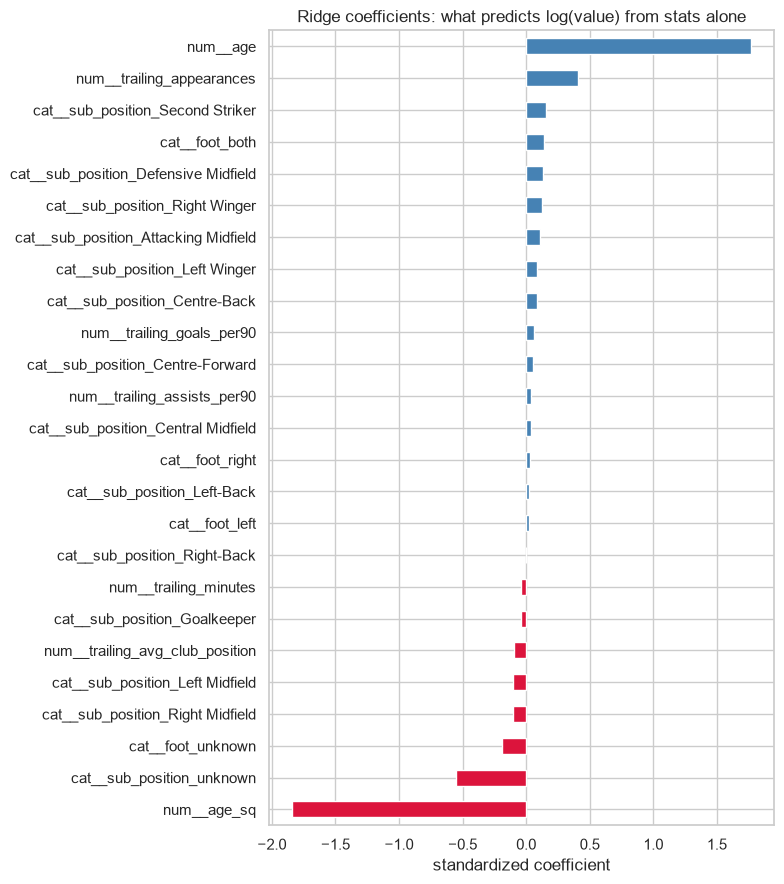

In [3]:
ridge_pipe = Pipeline([("preprocess", preprocessor), ("model", Ridge(alpha=1.0))])
ridge_pipe.fit(df[NUMERIC + CATEGORICAL], df["log_value"])
coefs = pd.Series(ridge_pipe.named_steps["model"].coef_, index=ridge_pipe.named_steps["preprocess"].get_feature_names_out())
coefs.sort_values().plot.barh(figsize=(8, 9), color=["crimson" if c < 0 else "steelblue" for c in coefs.sort_values()])
plt.title("Ridge coefficients: what predicts log(value) from stats alone")
plt.xlabel("standardized coefficient")
plt.tight_layout()
plt.show()

## Step 2: what correlates with the residual?

Two candidate "eye test" proxies, chosen because they're the ones most often invoked in football media commentary: playing for a historically glamorous club (even at development-squad level, since academy reputation-by-association is itself part of the phenomenon), and coming from one of football's largest media markets.

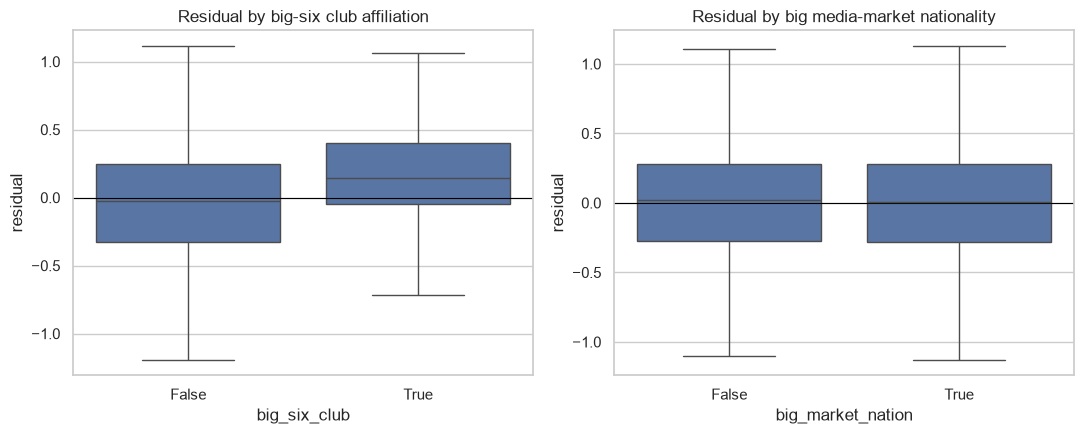

Mean residual, big-six club: {False: -0.046, True: 0.204}
Mean residual, big-market nation: {False: -0.002, True: 0.002}


In [4]:
BIG_SIX = ["Arsenal", "Chelsea", "Liverpool", "Manchester City", "Manchester United", "Tottenham Hotspur"]
BIG_MARKET_NATIONS = {"England", "Brazil", "France", "Argentina", "Spain", "Germany"}

df["big_six_club"] = df["current_club_name"].apply(lambda name: any(club in name for club in BIG_SIX))
df["big_market_nation"] = df["country_of_citizenship"].isin(BIG_MARKET_NATIONS)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df, x="big_six_club", y="residual", ax=axes[0], showfliers=False)
axes[0].set_title("Residual by big-six club affiliation")
axes[0].axhline(0, color="black", linewidth=0.8)

sns.boxplot(data=df, x="big_market_nation", y="residual", ax=axes[1], showfliers=False)
axes[1].set_title("Residual by big media-market nationality")
axes[1].axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Mean residual, big-six club:", df.groupby("big_six_club")["residual"].mean().round(3).to_dict())
print("Mean residual, big-market nation:", df.groupby("big_market_nation")["residual"].mean().round(3).to_dict())

**Reading the numbers**: the stats-only model explains 60% of the variance in log(value) out-of-fold — most of a player's value really is explained by age, output, and role. Of what's left, big-six affiliation shows a real gap: +0.20 vs. -0.05 mean residual, a ~0.25 log10-unit difference, i.e. big-six players are valued roughly **10^0.25 ≈ 1.8x** above what their stats alone would predict, relative to everyone else. Nationality/media-market size shows essentially **no** effect (+0.002 vs. -0.002) — once age, output, and role are accounted for, coming from a "bigger" football nation doesn't move the residual. That's a genuine finding, not a wash: it says the big-six premium isn't primarily a nationality story.

### Residual by sub-position

Flair positions (wingers, attacking midfielders) are the ones most associated with "eye test" appeal in football commentary, versus more utilitarian roles (defensive midfield, centre-back).

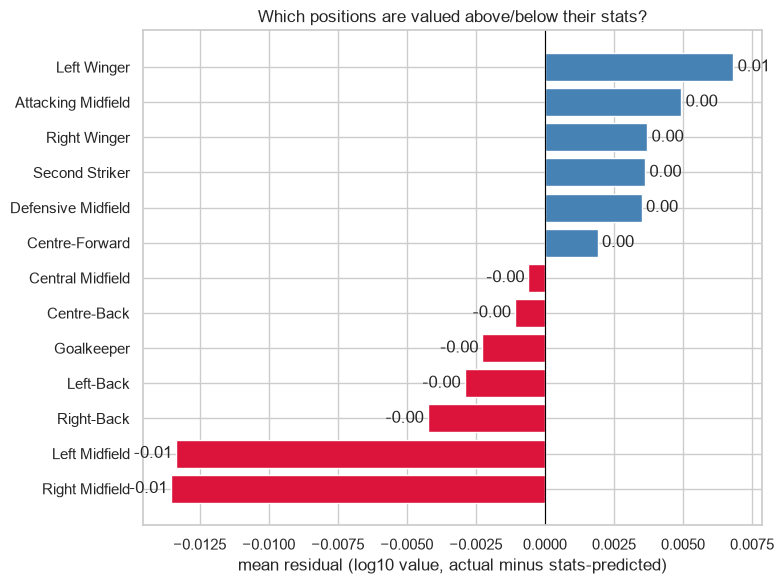

In [5]:
position_residual = df.groupby("sub_position")["residual"].agg(["mean", "count"])
position_residual = position_residual[position_residual["count"] >= 15].sort_values("mean")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["crimson" if v < 0 else "steelblue" for v in position_residual["mean"]]
bars = ax.barh(position_residual.index, position_residual["mean"], color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("mean residual (log10 value, actual minus stats-predicted)")
ax.set_title("Which positions are valued above/below their stats?")
plt.tight_layout()
plt.show()

## Most over- and under-valued relative to stats, right now

Using each player's latest snapshot only (not the full history), so a player isn't listed multiple times.

In [6]:
latest = latest_snapshot_per_player(df)
latest = latest.copy()
latest["current_value_usd_m"] = latest["current_value_eur"] * USD_PER_EUR / 1_000_000

display_cols = ["name", "sub_position", "current_club_name", "age", "current_value_usd_m", "residual"]

print("=== Valued most ABOVE their stats (candidate 'eye test premium') ===")
print(latest.sort_values("residual", ascending=False)[display_cols].head(10).round(2).to_string(index=False))

print("\n=== Valued most BELOW their stats (most underrated by the market) ===")
print(latest.sort_values("residual")[display_cols].head(10).round(2).to_string(index=False))

=== Valued most ABOVE their stats (candidate 'eye test premium') ===
               name     sub_position  current_club_name   age  current_value_usd_m  residual
       Mike Penders       Goalkeeper         Chelsea FC 19.87                12.96      1.71
     Giovanni Leoni      Centre-Back       Liverpool FC 19.45                27.00      1.68
       Sverre Nypan Central Midfield    Manchester City 19.46                14.04      1.17
    Malick Yalcouyé Central Midfield       Swansea City 20.52                12.96      1.12
       Abdul Fatawu     Right Winger     Leicester City 21.74                21.60      1.11
          Chido Obi   Centre-Forward  Manchester United 18.51                 5.40      1.09
       Jordan James Central Midfield     Leicester City 21.90                12.96      1.06
Samuel Iling-Junior    Left Midfield Pisa Sporting Club 22.47                 8.64      1.03
       Levi Colwill      Centre-Back         Chelsea FC 23.27                54.00      1.02
 

## Caveats

- This is a proxy, not a measurement of the eye test. The residual absorbs *everything* the model doesn't see — leadership, tactical discipline, set-piece threat, injury durability, contract leverage, agent negotiation — not just reputation effects.
- "Big six" and "big media market" are blunt, self-selected categories, not validated media-attention metrics.
- Survivorship bias: this dataset only contains players who made it to a professional Transfermarkt-tracked career, so there's no way to see players the eye test filtered *out* before they accumulated visible stats.
- Sample sizes vary a lot by sub-position and by nation, so some group means above are noisier than others (see the `count` column when reproducing the sub-position chart).